In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!cp "/content/drive/MyDrive/Datasets/spotify dataset.csv" "spotify dataset.csv"

Original number of features: 9
Reduced number of features (PCA components): 8

Calculating Inertia and Silhouette Scores for different values of k...

Optimal number of clusters (k): 2
Maximum Silhouette Score on original data: 0.1923


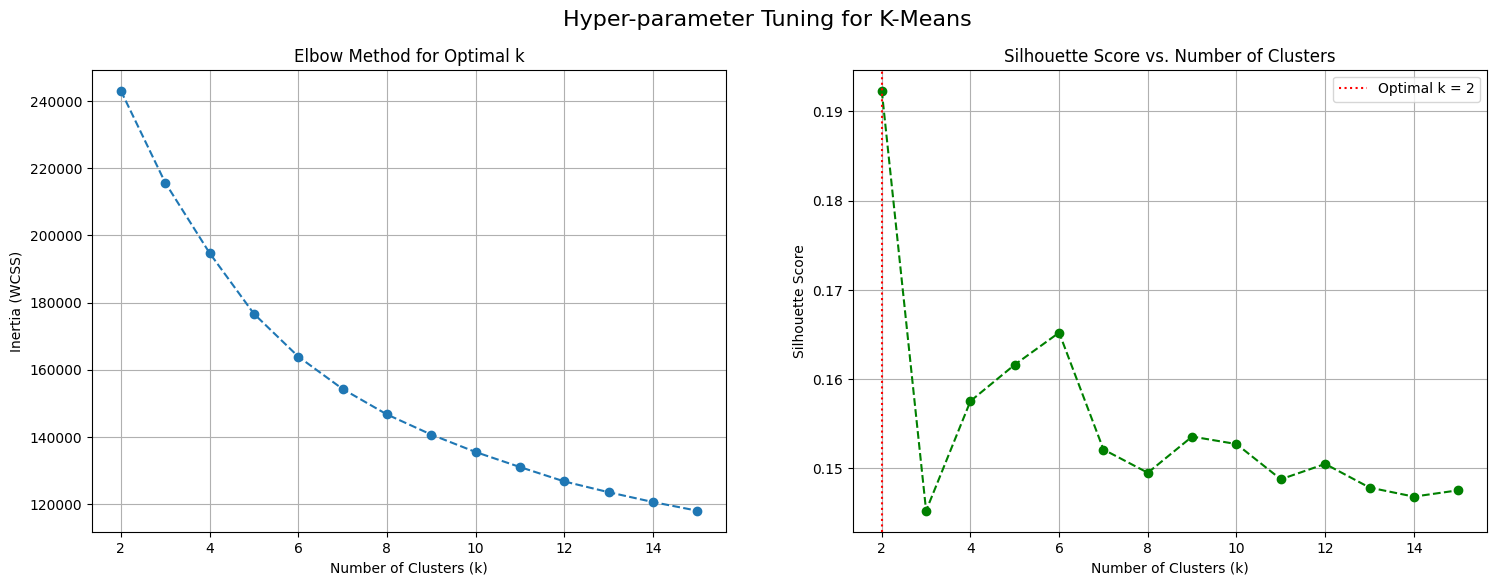


Found 2222 total poorly clustered data points.
Randomly selected 2222 outliers to remove (100.0%).
Original data points: 32828
Data points after random removal: 30606

Final Silhouette Score on filtered data: 0.2340
Score improved by 0.0417.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

# ==============================
# 1. Load and Clean Dataset
# ==============================
# Load the dataset
try:
    df = pd.read_csv("spotify dataset.csv")
except FileNotFoundError:
    print("Error: 'spotify dataset.csv' not found. Please make sure the file is in the correct directory.")
    exit()


# Drop rows with missing values and duplicates to ensure data quality
df = df.dropna()
df = df.drop_duplicates()
df = df.reset_index(drop=True)

# For this clustering task, we'll focus on the 6 main genres
main_genres = ['pop', 'rap', 'rock', 'latin', 'r&b', 'edm']
df_subset = df[df['playlist_genre'].isin(main_genres)].copy() # Use .copy() to avoid SettingWithCopyWarning

# ==============================
# 2. Feature Selection and Scaling
# ==============================
# Define the numerical audio features for clustering
features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

X = df_subset[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 3. Dimensionality Reduction with PCA
# ==============================
# Apply PCA to reduce the 9 features to a smaller number of components
pca = PCA(n_components=0.95) # Retain 95% of the variance
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Reduced number of features (PCA components): {X_pca.shape[1]}")

# ==============================
# 4. Hyper-tuning K-Means to Find Optimal 'k'
# ==============================
# We test values of k from 2 to 15 to find the best one
k_range = range(2, 16)
silhouette_scores = []
inertias = [] # To store inertia values for the elbow plot

print("\nCalculating Inertia and Silhouette Scores for different values of k...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)

    # Inertia for Elbow Method
    inertias.append(kmeans.inertia_)

    # Silhouette Score
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

# Find the optimal k that gives the highest Silhouette Score
optimal_k = k_range[np.argmax(silhouette_scores)]
max_score = max(silhouette_scores)

print(f"\nOptimal number of clusters (k): {optimal_k}")
print(f"Maximum Silhouette Score on original data: {max_score:.4f}")

# ==============================
# 4a. Visualize Hyper-tuning Results
# ==============================

# Plotting the Elbow Method and Silhouette Scores side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Elbow Method Plot
ax1.plot(k_range, inertias, marker='o', linestyle='--')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method for Optimal k")
ax1.grid(True)

# Silhouette Score Plot
ax2.plot(k_range, silhouette_scores, marker='o', linestyle='--', color='green')
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score vs. Number of Clusters")
ax2.axvline(x=optimal_k, color='red', linestyle=':', label=f'Optimal k = {optimal_k}')
ax2.legend()
ax2.grid(True)

plt.suptitle("Hyper-parameter Tuning for K-Means", fontsize=16)
plt.show()


# ==============================
# 5. Randomly Remove a Portion of Poorly Clustered Points
# ==============================

# Run K-Means with optimal_k to get the initial cluster labels
kmeans_initial = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
initial_labels = kmeans_initial.fit_predict(X_pca)

# Calculate the silhouette score for each individual sample
sample_scores = silhouette_samples(X_pca, initial_labels)
df_subset['silhouette_score'] = sample_scores

# Identify all points with negative silhouette scores (the outliers)
outliers_df = df_subset[df_subset['silhouette_score'] < 0]
print(f"\nFound {outliers_df.shape[0]} total poorly clustered data points.")

# --- CONTROL PARAMETER ---
# Set the percentage of outliers you want to remove
removal_percentage = 1.0
# -------------------------

# Randomly sample the outliers to be removed
if not outliers_df.empty:
    outliers_to_remove = outliers_df.sample(frac=removal_percentage, random_state=42)
    print(f"Randomly selected {outliers_to_remove.shape[0]} outliers to remove ({removal_percentage * 100}%).")

    # Get the indices to drop
    indices_to_drop = outliers_to_remove.index

    # Create the new filtered dataframe and PCA data by dropping the selected outliers
    df_filtered = df_subset.drop(indices_to_drop)
    X_pca_filtered = np.delete(X_pca, indices_to_drop, axis=0)
else:
    print("No outliers with negative scores found. Skipping removal.")
    df_filtered = df_subset.copy()
    X_pca_filtered = X_pca.copy()


print(f"Original data points: {df_subset.shape[0]}")
print(f"Data points after random removal: {df_filtered.shape[0]}")

# ==============================
# 6. Re-run Clustering on the Filtered Dataset
# ==============================
# Re-run K-Means on the cleaner data
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_labels = kmeans_final.fit_predict(X_pca_filtered)

# Calculate the new, improved silhouette score
final_silhouette_score = silhouette_score(X_pca_filtered, final_labels)

print(f"\nFinal Silhouette Score on filtered data: {final_silhouette_score:.4f}")
print(f"Score improved by {final_silhouette_score - max_score:.4f}.")

# ==============================
# 7. Visualize the New, Cleaner Clusters
# ==============================
# Add final cluster labels to the filtered dataframe for visualization
df_filtered = df_filtered.copy() # Create a copy to safely add the new column
df_filtered['cluster'] = final_labels

vis_df_filtered = pd.DataFrame(data=X_pca_filtered, columns=[f'PC_{i+1}' for i in range(X_pca_filtered.shape[1])])
vis_df_filtered['cluster'] = final_labels
vis_df_filtered['genre'] = df_filtered['playlist_genre'].values # Use .values to align correctly

fig = px.scatter(
    vis_df_filtered,
    x='PC_1',
    y='PC_2',
    color='cluster',
    hover_data=['genre'],
    title=f'Clusters after Randomly Removing {removal_percentage*100}% of Outliers (Score: {final_silhouette_score:.4f})',
    color_continuous_scale=px.colors.qualitative.Vivid
)
fig.show()


Created 3 new engineered features.

Running t-SNE for dimensionality reduction...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



t-SNE complete.
Original number of features (base + engineered): 12
Reduced number of features (t-SNE components): 2

Hyper-tuning K-Means on t-SNE data... (This may take a moment)

--- K-Means Tuning Complete ---
Optimal number of clusters (k): 3
Maximum Silhouette Score before outlier removal: 0.3750


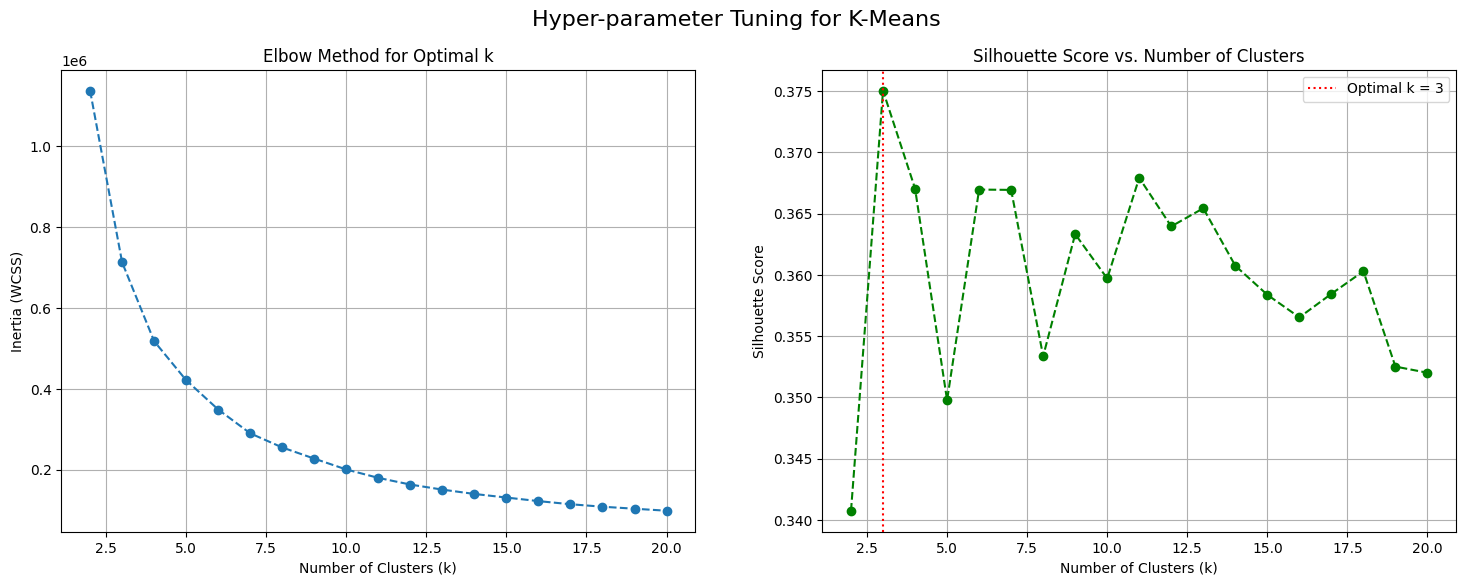


Found 201 total poorly clustered data points.
Randomly selecting 151 outliers to remove (75.0%).
Data points after random removal: 32677

Re-running K-Means on the cleaned dataset...

Final Silhouette Score on filtered data: 0.3776
Score improved by 0.0026.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE

# ==============================
# 1. Load and Clean Dataset
# ==============================
# Load the dataset
try:
    df = pd.read_csv("spotify dataset.csv")
except FileNotFoundError:
    print("Error: 'spotify dataset.csv' not found. Please make sure the file is in the correct directory.")
    exit()

# Drop rows with missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()
df = df.reset_index(drop=True)

# Focus on the 6 main genres
main_genres = ['pop', 'rap', 'rock', 'latin', 'r&b', 'edm']
df_subset = df[df['playlist_genre'].isin(main_genres)].copy()

# ==============================
# 2. Advanced Feature Engineering
# ==============================
# Define the base numerical audio features
base_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]
X_base = df_subset[base_features]

# Create new, more descriptive features
epsilon = 1e-6
X_engineered = X_base.copy()
X_engineered['rhythmic_complexity'] = X_base['tempo'] / (X_base['danceability'] + epsilon)
X_engineered['vocal_presence'] = X_base['speechiness'] / (X_base['instrumentalness'] + epsilon)
X_engineered['acoustic_vibe'] = X_base['acousticness'] / (X_base['energy'] + epsilon)

print("Created 3 new engineered features.")

# ==============================
# 3. Scaling and Dimensionality Reduction (t-SNE)
# ==============================
# Scale the combined base + engineered features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_engineered)

# Apply t-SNE to reduce dimensionality. t-SNE is excellent at separating clusters.
# It is computationally intensive, so this step may take a minute.
print("\nRunning t-SNE for dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE complete.")


print(f"Original number of features (base + engineered): {X_scaled.shape[1]}")
print(f"Reduced number of features (t-SNE components): {X_tsne.shape[1]}")

# ==============================
# 4. Hyper-tuning K-Means Model
# ==============================
k_range = range(2, 21)
best_score = -1
optimal_k = 2
inertias = []
silhouette_scores = []

print("\nHyper-tuning K-Means on t-SNE data... (This may take a moment)")
for k in k_range:
    # We use the t-SNE transformed data for clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_tsne)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_tsne, labels)
    silhouette_scores.append(score)

    if score > best_score:
        best_score = score
        optimal_k = k

print("\n--- K-Means Tuning Complete ---")
print(f"Optimal number of clusters (k): {optimal_k}")
print(f"Maximum Silhouette Score before outlier removal: {best_score:.4f}")

# ==============================
# 4a. Visualize K-Means Hyper-tuning Results
# ==============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Elbow Method Plot
ax1.plot(k_range, inertias, marker='o', linestyle='--')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method for Optimal k")
ax1.grid(True)

# Silhouette Score Plot
ax2.plot(k_range, silhouette_scores, marker='o', linestyle='--', color='green')
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score vs. Number of Clusters")
ax2.axvline(x=optimal_k, color='red', linestyle=':', label=f'Optimal k = {optimal_k}')
ax2.legend()
ax2.grid(True)

plt.suptitle("Hyper-parameter Tuning for K-Means", fontsize=16)
plt.show()


# ==============================
# 5. Optional: Remove a Portion of Poorly Clustered Points
# ==============================
# First, get the initial labels from the best K-Means model
kmeans_initial = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
initial_labels = kmeans_initial.fit_predict(X_tsne)
df_subset['silhouette_score'] = silhouette_samples(X_tsne, initial_labels)

# Identify all points with negative silhouette scores
outliers_df = df_subset[df_subset['silhouette_score'] < 0]
print(f"\nFound {outliers_df.shape[0]} total poorly clustered data points.")

# --- CONTROL PARAMETER ---
removal_percentage = 0.75  # Remove 75% of the identified outliers
# -------------------------

if not outliers_df.empty and removal_percentage > 0:
    outliers_to_remove = outliers_df.sample(frac=removal_percentage, random_state=42)
    print(f"Randomly selecting {outliers_to_remove.shape[0]} outliers to remove ({removal_percentage * 100}%).")

    indices_to_drop = outliers_to_remove.index
    df_filtered = df_subset.drop(indices_to_drop)
    X_tsne_filtered = np.delete(X_tsne, indices_to_drop, axis=0)

    print(f"Data points after random removal: {df_filtered.shape[0]}")

    # ==============================
    # 6. Re-run Clustering on the Filtered Dataset
    # ==============================
    print("\nRe-running K-Means on the cleaned dataset...")
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    final_labels = kmeans_final.fit_predict(X_tsne_filtered)
    final_silhouette_score = silhouette_score(X_tsne_filtered, final_labels)

    print(f"\nFinal Silhouette Score on filtered data: {final_silhouette_score:.4f}")
    print(f"Score improved by {final_silhouette_score - best_score:.4f}.")

else:
    print("\nSkipping outlier removal.")
    df_filtered = df_subset.copy()
    X_tsne_filtered = X_tsne.copy()
    final_labels = initial_labels
    final_silhouette_score = best_score


# ==============================
# 7. Final Clustering and Visualization
# ==============================
df_filtered = df_filtered.copy()
df_filtered['cluster'] = final_labels

vis_df_final = pd.DataFrame(data=X_tsne_filtered, columns=['t-SNE Component 1', 't-SNE Component 2'])
vis_df_final['cluster'] = final_labels
vis_df_final['genre'] = df_filtered['playlist_genre'].values

title_text = (
    f"K-Means Clusters (k={optimal_k}) after removing {removal_percentage*100}% of outliers | "
    f"Final Score: {final_silhouette_score:.4f}"
) if removal_percentage > 0 and not outliers_df.empty else (
    f"K-Means Clusters (k={optimal_k}) | Final Score: {final_silhouette_score:.4f}"
)


fig = px.scatter(
    vis_df_final,
    x='t-SNE Component 1',
    y='t-SNE Component 2',
    color='cluster',
    hover_data=['genre'],
    title=title_text,
    color_continuous_scale=px.colors.qualitative.Vivid
)
fig.show()
